# 木材含水率(MC)予測 — 特徴探索

NIR吸光度スペクトル（1000–2500 nm）から含水率 MC を予測するための **特徴探索（可視化のみ）**。
モデルの本実装はまだ行わず、「どの波長・どの特徴が MC と相関するか」「樹種ごとに関係がどう変わるか」を見る。

参照プラン: `feature_exploration_wood_MC.md`

**最重要の前提**: train と test の樹種は完全に別集合（trainに無い樹種を予測する）。
よって *未知樹種にも外挿できる特徴* かどうかを常に意識して相関を見る。


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.signal import savgol_filter

# 日本語フォント（macOS）
mpl.rcParams['font.family'] = 'Hiragino Sans'
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['figure.dpi'] = 110

# --- データ読み込み（Shift-JIS） ---
train = pd.read_csv('data/train.csv', encoding='shift_jis')
test  = pd.read_csv('data/test.csv',  encoding='shift_jis')

meta_cols = ['sample number', 'species number', '樹種', '含水率']
wn = train.columns[4:].astype(float).values          # 波数 [cm^-1]
nm = 1e7 / wn                                          # 波長 [nm]
X  = train[train.columns[4:]].values.astype(float)    # 吸光度 (n, p)
y  = train['含水率'].values                            # MC [%]
sp = train['樹種'].values

# 波長昇順に並べ替え（波数は降順で格納されている）
order = np.argsort(nm)
nm, X = nm[order], X[:, order]
wn = wn[order]

print('train:', train.shape, ' test:', test.shape)
print('波長範囲: %.1f–%.1f nm  (%d 点)' % (nm.min(), nm.max(), len(nm)))
print('MC範囲: %.1f–%.1f %%' % (y.min(), y.max()))
print('train 樹種:', sorted(train['species number'].unique()))
print('test  樹種:', sorted(test['species number'].unique()), '← trainと完全に別集合')

WATER = {'1450 nm (O–H 1st overtone)': 1450, '1940 nm (O–H combination)': 1940}
def idx_of(target_nm):
    return int(np.argmin(np.abs(nm - target_nm)))


train: (1322, 1559)  test: (550, 1558)
波長範囲: 1000.6–2500.1 nm  (1555 点)
MC範囲: 0.8–298.6 %
train 樹種: [np.int64(1), np.int64(3), np.int64(4), np.int64(5), np.int64(8), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19)]
test  樹種: [np.int64(2), np.int64(6), np.int64(7), np.int64(9), np.int64(10), np.int64(18)] ← trainと完全に別集合


## 1. データ概要 — 樹種ごとの含水率分布

,count,mean,std,min,max
樹種,,,,,
ウエンジ,87,15.5,12.4,4.2,58.7
トチ,183,31.6,29.3,13.3,153.8
ホワイトオーク,51,33.4,20.2,12.2,84.9
スプルース,97,37.1,42.8,0.8,160.1
ヒノキ,141,39.6,53.2,1.0,198.5
ナラ,107,41.8,25.7,16.9,114.1
ベイマツ,93,41.8,38.3,2.6,138.9
チェリー,88,53.4,49.7,4.1,158.9
ウォールナット,110,57.2,36.6,24.2,156.2


/var/folders/dh/5qgvv3mn3tlgcq_rb9k6l7xm0000gn/T/ipykernel_46915/387898163.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=species_sorted, patch_artist=True, showfliers=False)


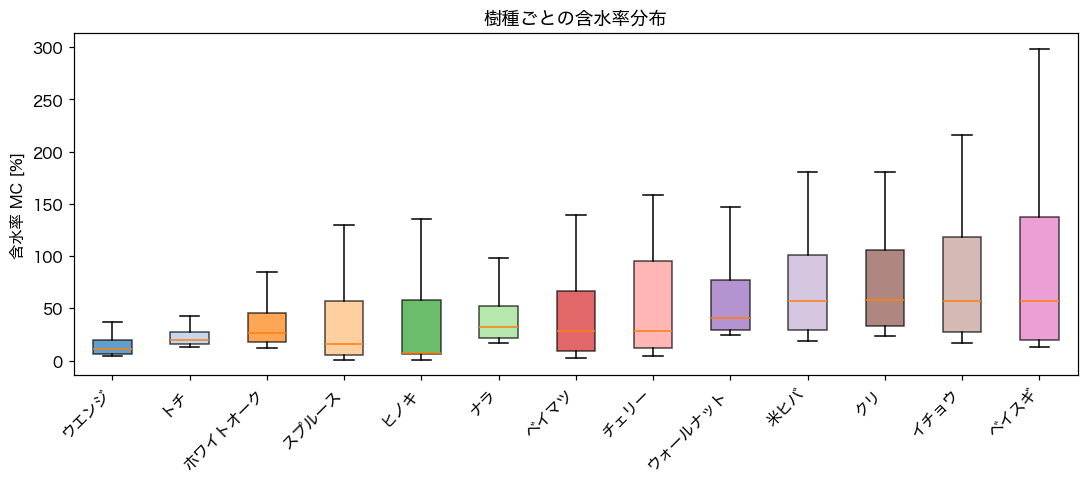

MCは樹種間で大きく異なる(中央値で約15〜88%)。樹種は強い交絡因子であり、
未知樹種に外挿するには「樹種に依存せずMCと結びつく特徴」を探す必要がある。


In [2]:
g = train.groupby('樹種')['含水率'].agg(['count','mean','std','min','max']).round(1)
g = g.sort_values('mean')
display(g)

species_sorted = g.index.tolist()
cmap = plt.get_cmap('tab20')
colors = {s: cmap(i % 20) for i, s in enumerate(species_sorted)}

fig, ax = plt.subplots(figsize=(10,4.5))
data = [train.loc[train['樹種']==s, '含水率'].values for s in species_sorted]
bp = ax.boxplot(data, labels=species_sorted, patch_artist=True, showfliers=False)
for patch, s in zip(bp['boxes'], species_sorted):
    patch.set_facecolor(colors[s]); patch.set_alpha(.7)
ax.set_ylabel('含水率 MC [%]'); ax.set_title('樹種ごとの含水率分布')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

print('MCは樹種間で大きく異なる(中央値で約15〜88%)。樹種は強い交絡因子であり、')
print('未知樹種に外挿するには「樹種に依存せずMCと結びつく特徴」を探す必要がある。')


## 2. 生スペクトル

吸光度スペクトルを (a) MC で色付け、(b) 樹種平均、で表示。
水バンド 1450 / 1940 nm を縦線で示す。

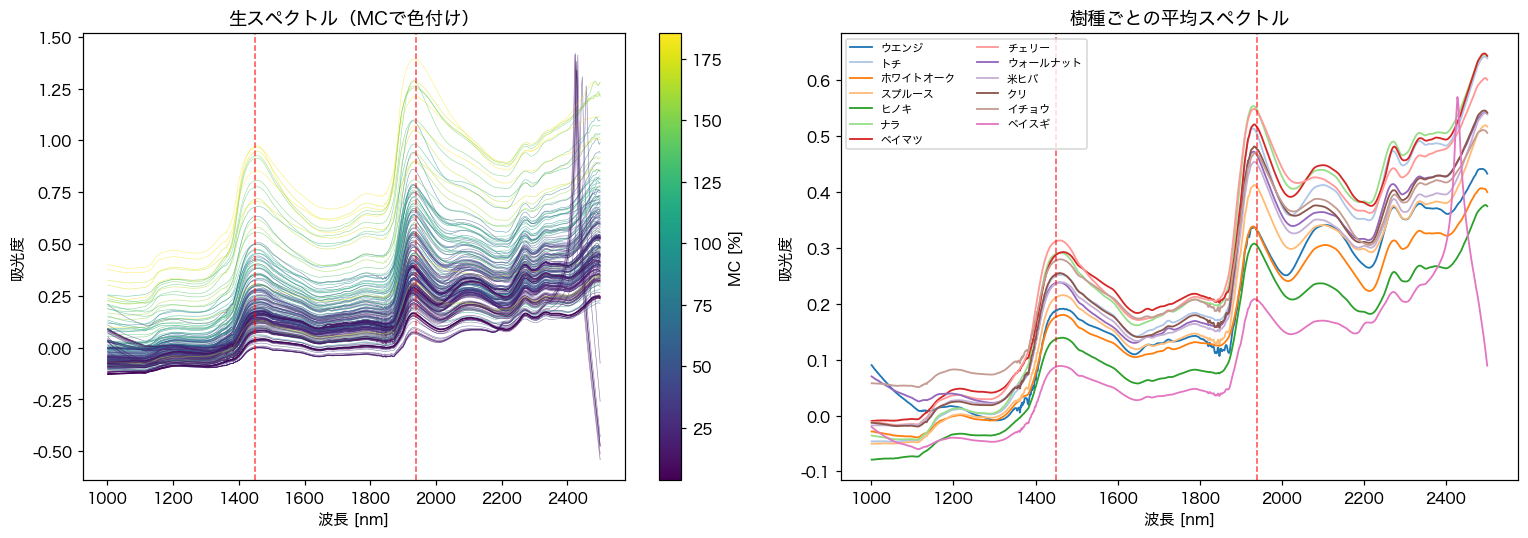

観察: 全体のベースライン高さ(散乱)が個体ごとに大きく違う → 散乱補正が必須。
水バンド1450/1940nm付近でMC高(黄)ほど吸光が強まる傾向が読み取れる。


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# (a) MCで色付け（見やすさのため最大250本サンプリング）
ax = axes[0]
rng = np.random.default_rng(0)
sel = rng.choice(len(X), size=min(250,len(X)), replace=False)
norm = mpl.colors.Normalize(vmin=np.percentile(y,2), vmax=np.percentile(y,98))
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
for i in sel:
    ax.plot(nm, X[i], color=sm.to_rgba(y[i]), lw=.4, alpha=.6)
for v in WATER.values(): ax.axvline(v, color='red', ls='--', lw=1, alpha=.7)
ax.set_title('生スペクトル（MCで色付け）'); ax.set_xlabel('波長 [nm]'); ax.set_ylabel('吸光度')
plt.colorbar(sm, ax=ax, label='MC [%]')

# (b) 樹種平均
ax = axes[1]
for s in species_sorted:
    ax.plot(nm, X[sp==s].mean(0), color=colors[s], lw=1.2, label=s)
for v in WATER.values(): ax.axvline(v, color='red', ls='--', lw=1, alpha=.7)
ax.set_title('樹種ごとの平均スペクトル'); ax.set_xlabel('波長 [nm]'); ax.set_ylabel('吸光度')
ax.legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

print('観察: 全体のベースライン高さ(散乱)が個体ごとに大きく違う → 散乱補正が必須。')
print('水バンド1450/1940nm付近でMC高(黄)ほど吸光が強まる傾向が読み取れる。')


## 3. 前処理（散乱補正・微分）

- **SNV**: 各スペクトルを平均0・分散1に行標準化（乗法散乱の補正）
- **SG 1次/2次微分**: ベースライン除去＋重なりピーク分離

前処理で「効く特徴」が変わるため、後段の相関は raw / SNV / SG2 の3系統で比較する。

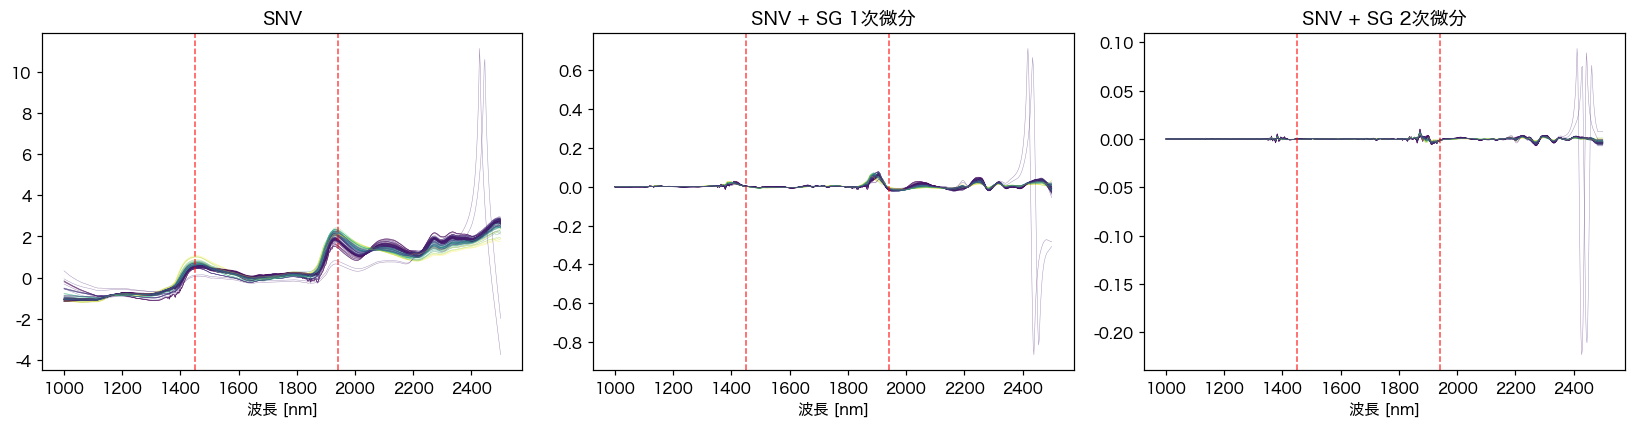

SNVでベースラインのばらつきが抑えられ、2次微分で水バンド近傍のピークが分離される。


In [4]:
def snv(M):
    return (M - M.mean(1, keepdims=True)) / M.std(1, keepdims=True)

X_snv = snv(X)
X_d1  = savgol_filter(X_snv, window_length=11, polyorder=2, deriv=1, axis=1)
X_d2  = savgol_filter(X_snv, window_length=15, polyorder=2, deriv=2, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, M, t in zip(axes, [X_snv, X_d1, X_d2], ['SNV', 'SNV + SG 1次微分', 'SNV + SG 2次微分']):
    for i in sel[:120]:
        ax.plot(nm, M[i], color=sm.to_rgba(y[i]), lw=.3, alpha=.5)
    for v in WATER.values(): ax.axvline(v, color='red', ls='--', lw=1, alpha=.7)
    ax.set_title(t); ax.set_xlabel('波長 [nm]')
plt.tight_layout(); plt.show()
print('SNVでベースラインのばらつきが抑えられ、2次微分で水バンド近傍のピークが分離される。')


## 4. 波長 × MC 相関スペクトル（コレログラム）

各波長の吸光度と MC のピアソン相関 r を波長軸に沿ってプロット。
|r| が高い波長帯が「MC予測に効く候補波長」。raw / SNV / SG2 を重ねて比較し、
水バンド 1450 / 1940 nm と整合するかを確認する。

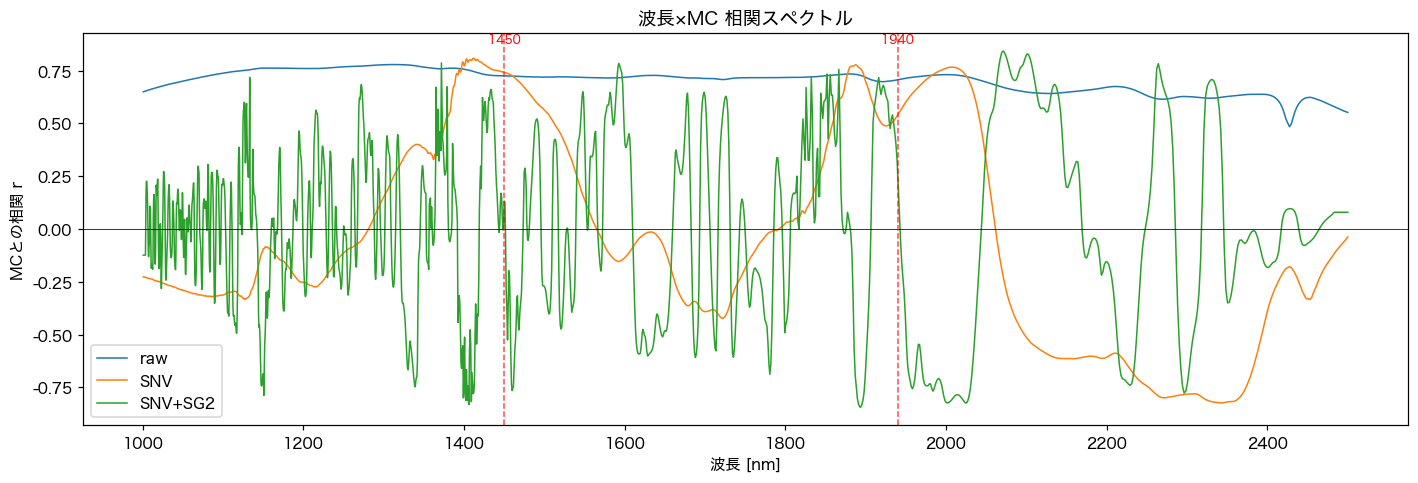

SNVで|r|が高い波長 (上位8):
  2344 nm : r=-0.82
  2342 nm : r=-0.82
  2340 nm : r=-0.82
  2346 nm : r=-0.82
  2338 nm : r=-0.82
  2336 nm : r=-0.82
  2348 nm : r=-0.82
  2334 nm : r=-0.82


In [5]:
def corr_with_y(M, yv):
    Mc = M - M.mean(0); yc = yv - yv.mean()
    return (Mc * yc[:,None]).sum(0) / (np.sqrt((Mc**2).sum(0)) * np.sqrt((yc**2).sum()) + 1e-12)

r_raw = corr_with_y(X,     y)
r_snv = corr_with_y(X_snv, y)
r_d2  = corr_with_y(X_d2,  y)

fig, ax = plt.subplots(figsize=(13,4.5))
ax.plot(nm, r_raw, label='raw',  lw=1)
ax.plot(nm, r_snv, label='SNV',  lw=1)
ax.plot(nm, r_d2,  label='SNV+SG2', lw=1)
ax.axhline(0, color='k', lw=.5)
for name,v in WATER.items():
    ax.axvline(v, color='red', ls='--', lw=1, alpha=.7)
    ax.text(v, ax.get_ylim()[1]*.95, name.split(' ')[0], color='red', fontsize=8, ha='center')
ax.set_xlabel('波長 [nm]'); ax.set_ylabel('MCとの相関 r'); ax.set_title('波長×MC 相関スペクトル')
ax.legend(); plt.tight_layout(); plt.show()

top = np.argsort(-np.abs(r_snv))[:8]
print('SNVで|r|が高い波長 (上位8):')
for i in top: print('  %.0f nm : r=%.2f' % (nm[i], r_snv[i]))


## 5. 樹種ごとの波長×MC 相関

全体で相関が高くても、それが「樹種間のMC平均差」由来だと未知樹種に外挿できない。
**樹種内（within-species）でも MC と相関する波長**こそ外挿に有効。
樹種ごとに波長×MC相関を計算し、ヒートマップで比較する。

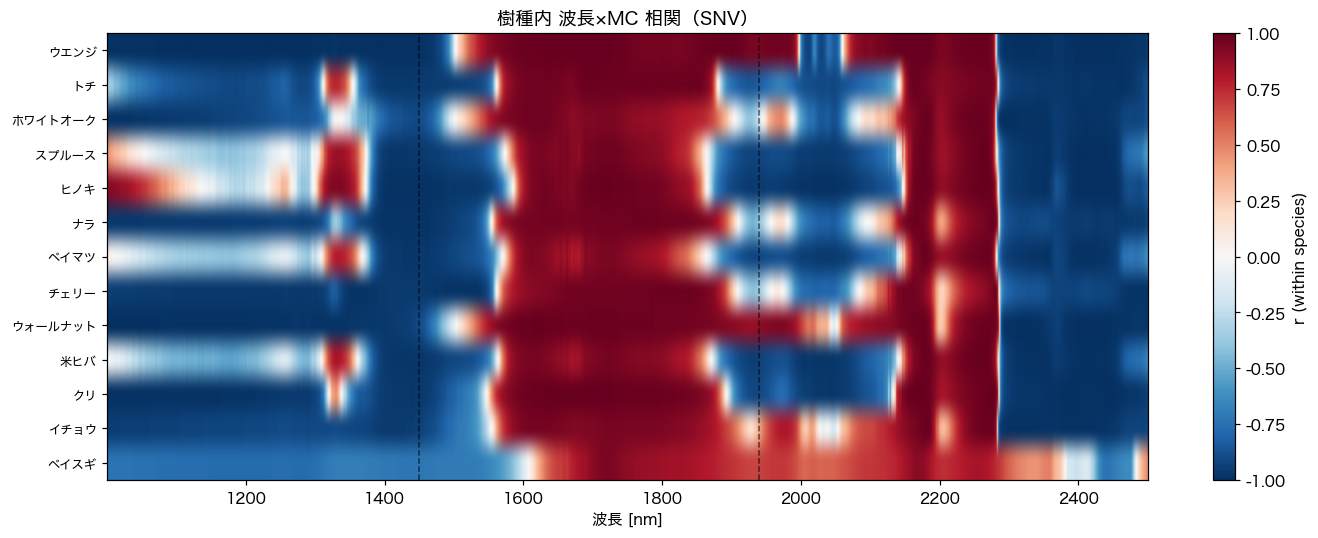

全樹種で符号が揃い|r|も高い波長(=外挿に強い候補, 上位8):
  1887 nm : 符号一致率 100%, 平均|r| 0.97
  1888 nm : 符号一致率 100%, 平均|r| 0.97
  1886 nm : 符号一致率 100%, 平均|r| 0.97
  1890 nm : 符号一致率 100%, 平均|r| 0.97
  1884 nm : 符号一致率 100%, 平均|r| 0.97
  1891 nm : 符号一致率 100%, 平均|r| 0.97
  1883 nm : 符号一致率 100%, 平均|r| 0.97
  1892 nm : 符号一致率 100%, 平均|r| 0.97


In [6]:
species_n = train['樹種'].value_counts()
use_sp = species_sorted   # 全樹種

R = np.zeros((len(use_sp), len(nm)))
for k, s in enumerate(use_sp):
    m = sp == s
    R[k] = corr_with_y(X_snv[m], y[m])

fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(R, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1,
               extent=[nm.min(), nm.max(), len(use_sp)-0.5, -0.5])
ax.set_yticks(range(len(use_sp))); ax.set_yticklabels(use_sp, fontsize=8)
for v in WATER.values(): ax.axvline(v, color='k', ls='--', lw=1, alpha=.6)
ax.set_xlabel('波長 [nm]'); ax.set_title('樹種内 波長×MC 相関（SNV）')
plt.colorbar(im, ax=ax, label='r (within species)'); plt.tight_layout(); plt.show()

# 全樹種共通で符号が揃う＝外挿に強い波長
sign_consistency = np.abs(np.sign(R).sum(0)) / len(use_sp)
mean_abs_r = np.abs(R).mean(0)
robust = np.argsort(-(sign_consistency * mean_abs_r))[:8]
print('全樹種で符号が揃い|r|も高い波長(=外挿に強い候補, 上位8):')
for i in robust:
    print('  %.0f nm : 符号一致率 %.0f%%, 平均|r| %.2f' % (nm[i], sign_consistency[i]*100, mean_abs_r[i]))


## 6. 波長帯のデータ駆動抽出（バンド幅をデータから決定）

単一波長の選択は **計測ノイズ・機器の波長シフト・過学習** に弱い。そこで波長帯（バンド）を使う。
ただし帯の中心・幅を手で決めず、**データから決める**。

手順:
1. セクション5の「外挿ロバスト性スコア」= 全樹種で符号一致率 × 樹種内平均|r| を波長軸に沿って評価。
2. スコアを軽く平滑化し、**しきい値（スコア分布の分位点）以上の連続区間**をバンドとして抽出。
   → バンドの **幅は連続区間の長さとしてデータが決める**（最小幅だけ下限を設ける）。
3. 各バンドの **平均吸光度** を特徴量にする（帯内平均でノイズが平均化され、単一波長より安定）。

しきい値はデータ駆動（分位点）で、その妥当性は感度分析（バンド数・被覆幅 vs しきい値）で確認する。

In [7]:
from scipy.ndimage import uniform_filter1d

# 外挿ロバスト性スコア（section5の量を再利用）。高い=全樹種で一貫してMCと相関
score   = sign_consistency * mean_abs_r
score_s = uniform_filter1d(score, size=9)        # 約9nmの平滑化（点間隔≈1nm）

def within_species_r(v):
    return np.array([np.corrcoef(v[sp==s], y[sp==s])[0,1] for s in species_sorted])

def detect_bands(thr, min_width_nm=20):
    """score_s>=thr の連続区間をバンドとして抽出"""
    above = score_s >= thr
    out, i, n = [], 0, len(nm)
    while i < n:
        if above[i]:
            j = i
            while j < n and above[j]:
                j += 1
            lo, hi = nm[i], nm[j-1]
            if hi - lo >= min_width_nm:
                seg = slice(i, j)
                out.append({'lo': lo, 'hi': hi,
                            'center': nm[i:j][int(np.argmax(score_s[i:j]))],
                            'width_nm': hi - lo, 'peak_score': float(score_s[i:j].max()),
                            'slice': seg})
            i = j
        else:
            i += 1
    return out

# しきい値はデータ駆動：スコア分布の上位20%
Q = 0.80
thr = float(np.quantile(score_s, Q))
bands = detect_bands(thr)

band_tbl = pd.DataFrame([{k: round(v,3) if isinstance(v,float) else v
                          for k,v in b.items() if k!='slice'} for b in bands])
print('しきい値 = 分位点%.2f = %.3f / 検出バンド数 = %d' % (Q, thr, len(bands)))
display(band_tbl)


しきい値 = 分位点0.80 = 0.928 / 検出バンド数 = 5


,lo,hi,center,width_nm,peak_score
0,1190.365,1224.665,1209.242,34.300,0.944
1,1375.393,1469.737,1406.737,94.344,0.968
2,1866.534,1903.536,1886.911,37.002,0.973
3,1985.158,2041.430,2028.651,56.272,0.964
4,2314.836,2405.024,2359.068,90.188,0.960


### 6.1 抽出バンドの可視化

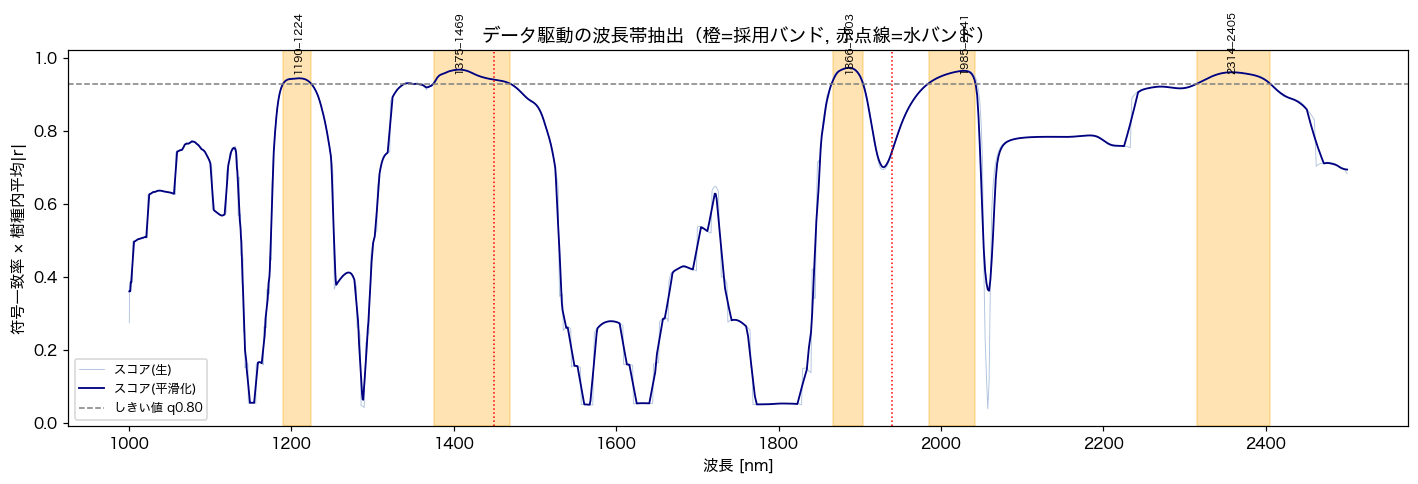

In [8]:
fig, ax = plt.subplots(figsize=(13,4.5))
ax.plot(nm, score, color='lightsteelblue', lw=.6, label='スコア(生)')
ax.plot(nm, score_s, color='navy', lw=1.2, label='スコア(平滑化)')
ax.axhline(thr, color='gray', ls='--', lw=1, label='しきい値 q%.2f' % Q)
for b in bands:
    ax.axvspan(b['lo'], b['hi'], color='orange', alpha=.3)
    ax.text(b['center'], thr*1.03, '%d–%d' % (int(b['lo']), int(b['hi'])),
            fontsize=7, ha='center', va='bottom', rotation=90)
for v in WATER.values(): ax.axvline(v, color='red', ls=':', lw=1)
ax.set_xlabel('波長 [nm]'); ax.set_ylabel('符号一致率 × 樹種内平均|r|')
ax.set_title('データ駆動の波長帯抽出（橙=採用バンド, 赤点線=水バンド）')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()


### 6.2 バンド平均特徴 vs 単一波長 — 安定性の比較

,band,width_nm,全体r,樹種内r平均,樹種内r標準偏差(帯平均),樹種内r標準偏差(単一波長平均)
0,B1_1190-1224nm,34.3,-0.259,-0.942,0.070,0.071
1,B2_1375-1469nm,94.3,0.779,0.958,0.028,0.035
2,B3_1866-1903nm,37.0,0.742,0.974,0.031,0.034
3,B4_1985-2041nm,56.3,0.739,0.957,0.053,0.053
4,B5_2314-2405nm,90.2,-0.786,-0.960,0.068,0.093


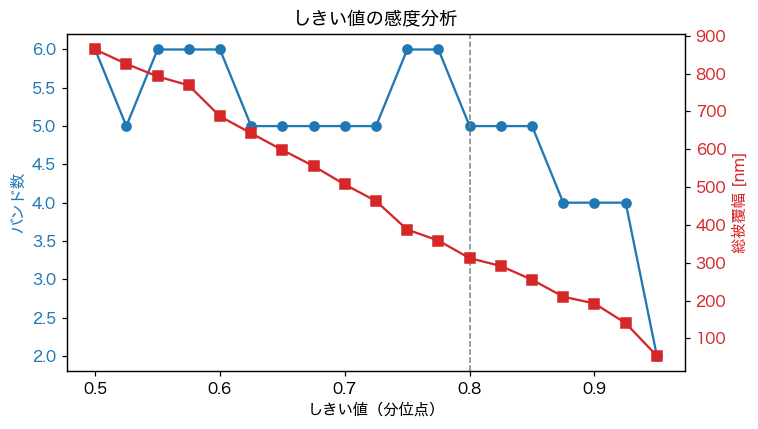

帯平均特徴の樹種内r標準偏差は、同じ帯の単一波長より小さい → 帯平均がばらつきを抑え安定。


In [9]:
# 各バンドの平均吸光度を特徴に
rows, band_feats = [], {}
for k, b in enumerate(bands):
    v = X_snv[:, b['slice']].mean(1)
    name = 'B%d_%d-%dnm' % (k+1, int(b['lo']), int(b['hi']))
    band_feats[name] = v
    wr_band = within_species_r(v)
    # 同じ帯内の単一波長それぞれの樹種内r（ばらつきの比較用）
    wr_single = np.array([within_species_r(X_snv[:, ii]) for ii in range(b['slice'].start, b['slice'].stop)])
    rows.append({'band': name, 'width_nm': round(b['width_nm'],1),
                 '全体r': round(np.corrcoef(v,y)[0,1],3),
                 '樹種内r平均': round(np.nanmean(wr_band),3),
                 '樹種内r標準偏差(帯平均)': round(np.nanstd(wr_band),3),
                 '樹種内r標準偏差(単一波長平均)': round(np.nanmean(np.nanstd(wr_single,axis=1)),3)})
band_feat_tbl = pd.DataFrame(rows)
display(band_feat_tbl)

# 感度分析：しきい値を変えるとバンド数・総被覆幅がどう変わるか
qs = np.linspace(0.5, 0.95, 19)
ncnt, cov = [], []
for q in qs:
    bb = detect_bands(float(np.quantile(score_s, q)))
    ncnt.append(len(bb)); cov.append(sum(b['width_nm'] for b in bb))

fig, ax1 = plt.subplots(figsize=(7,4))
ax1.plot(qs, ncnt, 'o-', color='tab:blue'); ax1.set_xlabel('しきい値（分位点）')
ax1.set_ylabel('バンド数', color='tab:blue'); ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.axvline(Q, color='gray', ls='--', lw=1)
ax2 = ax1.twinx(); ax2.plot(qs, cov, 's-', color='tab:red')
ax2.set_ylabel('総被覆幅 [nm]', color='tab:red'); ax2.tick_params(axis='y', labelcolor='tab:red')
ax1.set_title('しきい値の感度分析'); plt.tight_layout(); plt.show()

print('帯平均特徴の樹種内r標準偏差は、同じ帯の単一波長より小さい → 帯平均がばらつきを抑え安定。')


## 7. バンド形状・比指標などの設計特徴

物理的に解釈できる軽量特徴を作り、MC との関係を散布図で確認する。

- **バンド深さ**: 連続体（両肩を結ぶ直線）からの水バンドの深さ（1450 / 1940 nm）
- **比指標**: A(1940)/A(参照1300nm) など散乱の乗法成分を比でキャンセル
- **積分強度**: 水バンド近傍の吸光度和

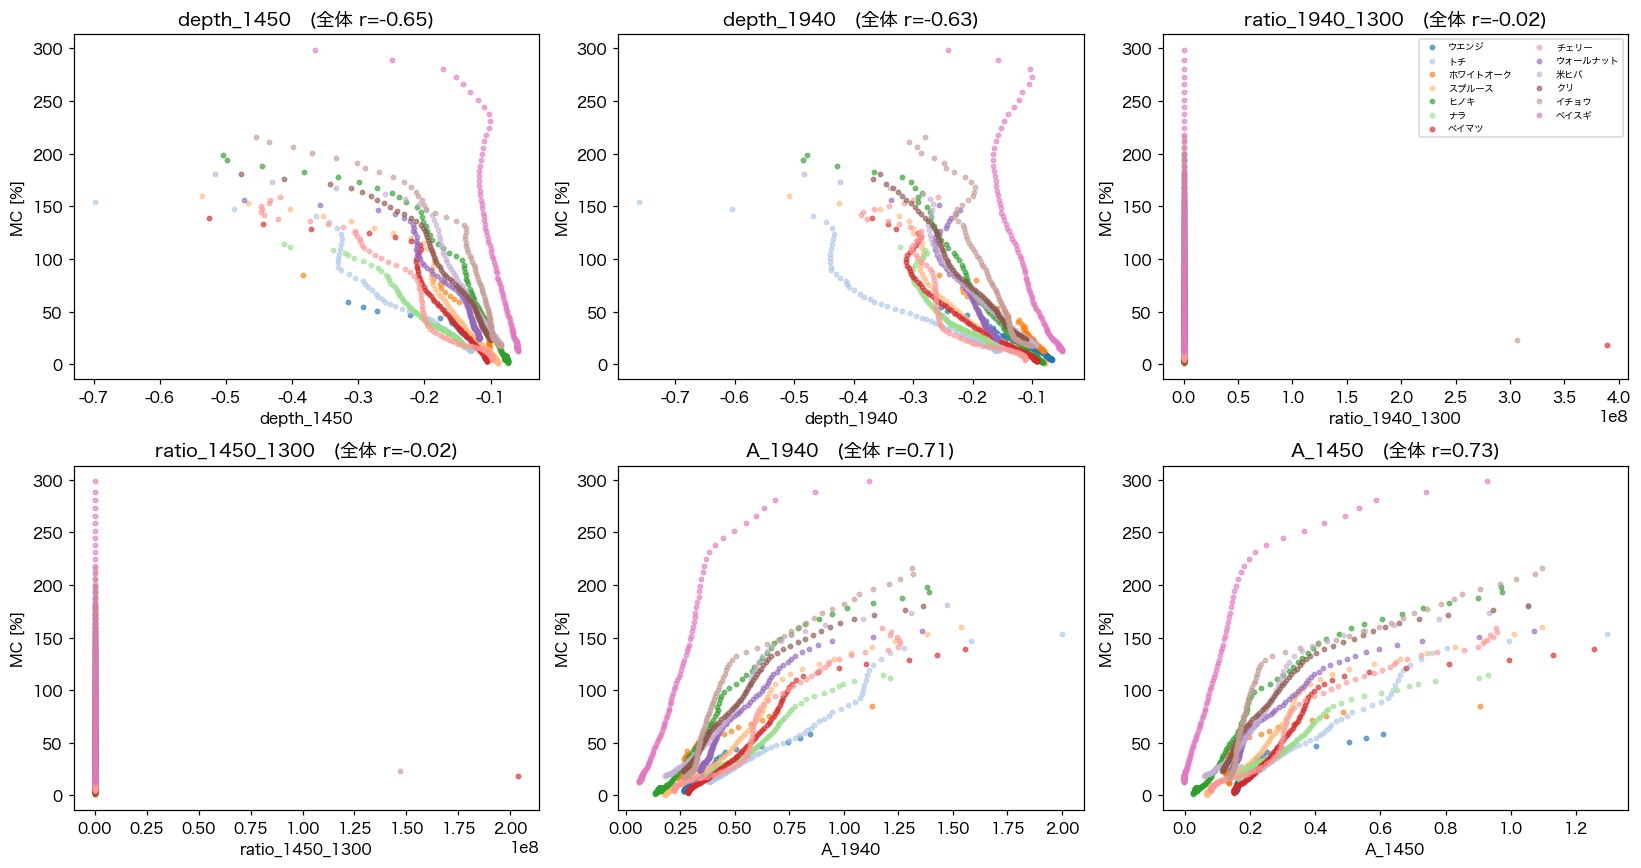

In [10]:
def band_depth(M, center, left, right):
    """両肩(left,right)を結ぶ直線を連続体とし、centerでの深さを返す"""
    ic, il, ir = idx_of(center), idx_of(left), idx_of(right)
    cont = M[:, il] + (M[:, ir]-M[:, il]) * (nm[ic]-nm[il])/(nm[ir]-nm[il])
    return cont - M[:, ic]

feat = pd.DataFrame({
    'depth_1450': band_depth(X, 1450, 1300, 1600),
    'depth_1940': band_depth(X, 1940, 1800, 2050),
    'ratio_1940_1300': X[:, idx_of(1940)] / (X[:, idx_of(1300)] + 1e-9),
    'ratio_1450_1300': X[:, idx_of(1450)] / (X[:, idx_of(1300)] + 1e-9),
    'A_1940': X[:, idx_of(1940)],
    'A_1450': X[:, idx_of(1450)],
})
feat['MC'] = y; feat['樹種'] = sp

fcols = [c for c in feat.columns if c not in ('MC','樹種')]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.ravel(), fcols):
    for s in species_sorted:
        m = sp == s
        ax.scatter(feat.loc[m, c], y[m], s=8, alpha=.6, color=colors[s], label=s)
    r = np.corrcoef(feat[c], y)[0,1]
    ax.set_title('%s   (全体 r=%.2f)' % (c, r)); ax.set_xlabel(c); ax.set_ylabel('MC [%]')
axes[0,2].legend(fontsize=6, ncol=2, loc='upper right')
plt.tight_layout(); plt.show()


### 7.1 設計特徴の相関 — 全体 vs 樹種内平均

In [11]:
rows = []
for c in fcols:
    r_all = np.corrcoef(feat[c], y)[0,1]
    rs = [np.corrcoef(feat.loc[sp==s, c], y[sp==s])[0,1] for s in species_sorted]
    rows.append({'特徴': c, '全体r': round(r_all,3),
                 '樹種内r平均': round(np.nanmean(rs),3),
                 '樹種内r最小': round(np.nanmin(rs),3),
                 '樹種内r最大': round(np.nanmax(rs),3)})
corr_tbl = pd.DataFrame(rows).sort_values('樹種内r平均', key=lambda s: s.abs(), ascending=False)
display(corr_tbl)
print('「全体r」と「樹種内r平均」がともに高い特徴 = 樹種に依存せずMCと結びつく → 外挿に有望。')
print('全体rだけ高く樹種内rが低い特徴は、樹種間のMC差を拾っているだけで未知樹種に弱い。')


,特徴,全体r,樹種内r平均,樹種内r最小,樹種内r最大
1,depth_1940,-0.633,-0.949,-0.994,-0.849
4,A_1940,0.707,0.945,0.847,0.985
5,A_1450,0.725,0.903,0.756,0.975
0,depth_1450,-0.653,-0.895,-0.977,-0.741
3,ratio_1450_1300,-0.023,0.060,-0.098,0.248
2,ratio_1940_1300,-0.023,0.054,-0.098,0.235


「全体r」と「樹種内r平均」がともに高い特徴 = 樹種に依存せずMCと結びつく → 外挿に有望。
全体rだけ高く樹種内rが低い特徴は、樹種間のMC差を拾っているだけで未知樹種に弱い。


## 8. PCA による構造把握

SNVスペクトルを PCA で2次元に圧縮し、(a) 樹種、(b) MC で色付け。
MC勾配が主成分軸に沿って現れれば、その軸方向の特徴がMCを担う。
樹種クラスタが分離しているほど、樹種交絡が強いことを意味する。

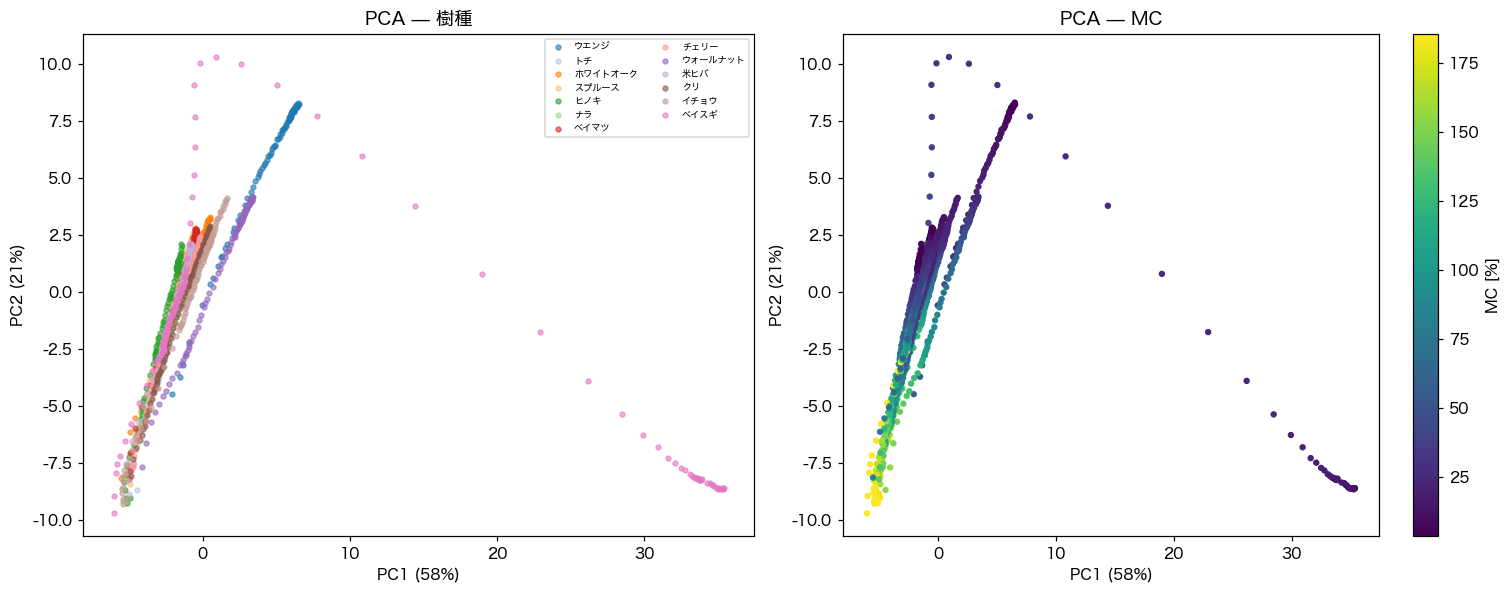

各PCとMCの相関:
  PC1 (寄与58%): r=-0.34
  PC2 (寄与21%): r=-0.70
  PC3 (寄与10%): r=-0.36
  PC4 (寄与5%): r=0.05
  PC5 (寄与2%): r=-0.17


In [12]:
from sklearn.decomposition import PCA
Z = PCA(n_components=5, random_state=0).fit(X_snv)
T = Z.transform(X_snv)
ev = Z.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14,5.5))
for s in species_sorted:
    m = sp == s
    axes[0].scatter(T[m,0], T[m,1], s=10, alpha=.6, color=colors[s], label=s)
axes[0].legend(fontsize=6, ncol=2); axes[0].set_title('PCA — 樹種')
sc = axes[1].scatter(T[:,0], T[:,1], c=y, cmap='viridis', s=10,
                     norm=mpl.colors.Normalize(*np.percentile(y,[2,98])))
plt.colorbar(sc, ax=axes[1], label='MC [%]'); axes[1].set_title('PCA — MC')
for ax in axes:
    ax.set_xlabel('PC1 (%.0f%%)' % (ev[0]*100)); ax.set_ylabel('PC2 (%.0f%%)' % (ev[1]*100))
plt.tight_layout(); plt.show()

# 各主成分とMCの相関
print('各PCとMCの相関:')
for k in range(5):
    print('  PC%d (寄与%.0f%%): r=%.2f' % (k+1, ev[k]*100, np.corrcoef(T[:,k], y)[0,1]))


## まとめ（特徴探索の所見）

1. **散乱が大きい** → SNV等の散乱補正が前処理として必須。
2. **水バンド 1450 / 1940 nm** が MC と相関する主要波長として相関スペクトルで確認できる。SG2次微分でバンドが分離。
3. **樹種は強い交絡**: MC平均が樹種間で大きく異なる。全体相関が高くても樹種内で相関しない特徴は、未知樹種(test)に外挿できない。
4. **外挿に有望な特徴** = 全樹種で符号が揃い樹種内でもMCと相関する波長／バンド深さ。これらを優先候補とする。
   - 単一波長はノイズ・波長シフト・過学習に弱いため、ロバスト性スコアの連続区間から**バンド幅をデータ駆動で決定**し、帯内平均を特徴化（セクション6）。帯平均は単一波長より樹種内相関のばらつきが小さく安定。
5. 次段: ここで絞った波長・バンド特徴を使い、グループ(樹種)CVで PLS / 非線形モデルを比較する（本実装は別途）。
